<a href="https://colab.research.google.com/github/RitaDCassia/swin_transformer/blob/main/swin_estradas_sentinel2_v5_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Swin Transformer híbrido para segmentação de estradas em Sentinel-2 (Rondônia)

**Base:** tiles 512x512 exportados do Google Earth Engine para o Drive (`swin_tiles_img/img_*.tif` e `swin_tiles_mask/mask_*.tif`). Não há recorte: os tiles já saem do GEE no tamanho final.

O pipeline de dados e de avaliação segue o notebook do U-Net com MiT-B3: mesma regra de pareamento e mesmos filtros de tiles, mesmo stretch de reflectância (0 a 0,35 vira 0 a 1, seguido da normalização ImageNet), loss com a mesma estrutura (BCE com peso 4 na estrada + Dice + 0,5 x clDice) e as mesmas métricas (IoU global com limiar 0,5 e IoU relaxado com tolerância de 3 px).

**A divisão é nova.** A pasta tem tiles repetidos: a mesma célula da grade foi sorteada por sementes diferentes. Numa divisão aleatória por arquivo, mais da metade da validação tinha cópia idêntica no treino. Agora as cópias viram uma só, tiles sobrepostos ficam sempre no mesmo conjunto e há um conjunto de teste separado. O resultado anterior do MiT-B3 (vIoU 0,4681) veio de uma versão menor da base, com divisão aleatória por arquivo, e não é comparável. Para comparar, rode o experimento D (`BACKBONE = "mitb3"`) neste mesmo notebook: mesmos dados, mesma divisão, mesma loss e mesmas métricas.

**Correções no Swin** (marcadas no código como `[CORREÇÃO N]`):

1. **Atenção desligada.** O `einsum` final da `WindowAttention` indexava `v` com `i` em vez de `j`; a saída era o próprio V e Q, K, `tau` e o embedding de posição não recebiam gradiente.
2. **Temperatura da atenção por cosseno.** O `tau` era livre e caía rápido quando a atenção passava a funcionar. Agora segue o Swin V2 (escala em log, limitada a 100).
3. **Loss.** Saíram o `pos_weight=30` e o Tversky com `beta=0.7`, que empurravam o modelo a engordar as estradas.
4. **Métrica.** IoU global (TP, FP e FN somados no conjunto inteiro) com limiar fixo, sem o ajuste automático de limiar.
5. **Dados.** Pares imagem/máscara desalinhados são descartados; tiles repetidos ou sobrepostos nunca ficam em conjuntos diferentes.
6. **Erro `test_imgs`** removido.
7. **Avaliação final com o melhor checkpoint**, no conjunto de teste.
8. **Pós-processamento** sem a abertura morfológica 3x3, que apagava estradas finas.
9. **NaN na precisão mista.** Um lote com estouro numérico em fp16 corrompia as estatísticas da BatchNorm e zerava a validação até o fim do treino. Agora a L4 e a A100 usam bf16, que tem a mesma faixa de valores do fp32; e um lote com NaN é ignorado sem mexer na BatchNorm.

**Como rodar:** ative a GPU (Ambiente de execução > Alterar o tipo de ambiente de execução > GPU) e execute as células em ordem. A Célula 5a lê todos os tiles do Drive e é lenta (alguns minutos, uma vez por sessão). A Célula 5b faz a divisão e é rápida: para mudar a divisão, altere a Célula 2 e rode de novo a 2 e a 5b, sem reler o Drive. A Célula 8b mede o custo computacional (parâmetros, operações por tile, tempo e memória na GPU) e estima o tempo de treino. A Célula 9 treina, escolhe o limiar na validação, reporta os números finais no teste e acrescenta uma linha em `experimentos.csv`, com resultado e custo de cada treino. Checkpoints, figuras, o arquivo de divisão e a planilha desta versão vão para `MyDrive/swin_s2_comparacao`. A pasta do modelo C (`MyDrive/swin_s2_checkpoints`) não é alterada: a Célula 5b só lê de lá a divisão usada pelo C e confere se é idêntica à atual.

**Experimentos sugeridos (mude só a Célula 2 e rode de novo as Células 2 a 9, exceto a 5a):**

| Experimento | `BACKBONE` | `USE_CNN_STEM` | `PRETRAINED` | Papel no delineamento |
|---|---|---|---|---|
| C | `"timm"` | `True` | `True` | modelo proposto; já treinado na versão 4 (não precisa rodar de novo) |
| B | `"timm"` | `False` | `True` | ablação: sem o ramo CNN de resolução cheia |
| G | `"timm"` | `True` | `False` | ablação: sem pré-treino no ImageNet |
| E | `"unet"` | (ignorado) | `True` | linha de base CNN: U-Net com encoder ResNet-34 |
| F | `"segformer"` | (ignorado) | `True` | referência Transformer: SegFormer-B2 |
| D | `"mitb3"` | (ignorado) | `True` | opcional: U-Net com encoder MiT-B3 (continuidade com o experimento antigo) |
| A | `"scratch"` | `False` | (ignorado) | opcional: o seu Swin original, só com os erros corrigidos |

O Swin-UNet (referência Transformer pura) entra quando o código dele for integrado. Use a mesma `SPLIT_SEED` em todos os experimentos, para que todos vejam os mesmos tiles; para as repetições, mude só a `SEED` (a semente do treino entra no nome do checkpoint e na planilha).

**Validação espacial:** com `SPLIT_MODE = "quadrante"`, o `QUADRANTE_TESTE` inteiro vira teste e a validação é sorteada nos outros três quadrantes. É o teste mais forte de generalização para a dissertação.

**Outra base (por exemplo, a v2 do `export_tiles_v2.py`):** troque `IMG_DIR` e `MASK_DIR`; confira na saída da Célula 5a o número e o nome das bandas e ajuste `BANDAS_LEITURA` para que as três primeiras sejam R, G e B; use `MIN_ROAD_RATIO = 0.0` se a base tiver tiles negativos (sem estrada) de propósito.

In [1]:
# ============================================================
# CÉLULA 1: Drive e bibliotecas
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

%pip install -q timm einops rasterio segmentation-models-pytorch

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 13.6 MB/s eta 0:00:00


In [2]:
# ============================================================
# CÉLULA 2: Importações e CONFIGURAÇÃO
# (tudo o que você costuma mudar entre experimentos fica aqui)
# Depois de mudar algo aqui, rode de novo as Células 2 a 9
# (ou Ambiente de execução > Executar tudo).
# ============================================================
import csv
import json
import math
import random
import time
from datetime import datetime
from collections import Counter
from pathlib import Path

import numpy as np
import torch
from torch import nn, einsum
import torch.nn.functional as F
from einops import rearrange
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import cv2
import rasterio
from rasterio.warp import transform as warp_transform

# ---------- Dados: tiles Sentinel-2 exportados do GEE ----------
IMG_DIR  = Path("/content/drive/MyDrive/swin_tiles_img")    # img_*.tif
MASK_DIR = Path("/content/drive/MyDrive/swin_tiles_mask")   # mask_*.tif (mesmo nome, com mask_ no lugar de img_)
CKPT_DIR = Path("/content/drive/MyDrive/swin_s2_comparacao")   # pasta própria desta versão
# O modelo C (versão 4) fica intocado em MyDrive/swin_s2_checkpoints: esta versão não grava nada
# lá, só LÊ o arquivo de divisão, para conferir que todos os modelos usam exatamente os mesmos tiles.
DIVISAO_REFERENCIA = Path("/content/drive/MyDrive/swin_s2_checkpoints/divisao_posicao_seed42.csv")

BANDAS_LEITURA   = None    # None: todas as bandas, na ordem do arquivo (base atual: B4, B3, B2 = R, G, B)
                           # Lista 1-indexada para escolher/reordenar, ex.: [3, 2, 1, 4]
                           # As três primeiras bandas lidas precisam ser R, G, B (pesos do ImageNet)
REFLECTANCE_MAX  = 0.35    # stretch 0-0,35 -> 0-1 em R, G, B (igual ao notebook do MiT-B3)
TARGET_SIZE      = 512     # tiles com 1 ou 2 px a mais/menos são completados/cortados
MIN_ROAD_RATIO   = 0.002   # descarta tiles com menos de 0,2% de estrada. Base com tiles negativos: 0.0
MAX_NODATA_RATIO = 0.10    # descarta tiles com mais de 10% de pixels sem dado

# ---------- Divisão treino/validação/teste ----------
SPLIT_MODE      = "posicao"   # "posicao": sorteio por posição geográfica; tiles repetidos ou sobrepostos
                              #            ficam sempre no mesmo conjunto (cópias viram uma só)
                              # "quadrante": QUADRANTE_TESTE inteiro vira teste (generalização espacial)
VAL_FRACTION    = 0.15        # validação: escolhe o checkpoint e o limiar
TEST_FRACTION   = 0.15        # teste: só para os números finais (modo "posicao")
SPLIT_SEED      = 42
QUADRANTE_TESTE = "SE"        # modo "quadrante": "NW", "NE", "SW" ou "SE"
LON_MEIO, LAT_MEIO = None, None   # divisa dos quadrantes; None = centro do retângulo que envolve os tiles

# ---------- Arquitetura ----------
BACKBONE     = "timm"      # "timm": Swin-T (modelo proposto) | "scratch": Swin da Célula 3, do zero
                           # "unet": U-Net + ResNet-34 (linha de base CNN) | "segformer": SegFormer
                           # "mitb3": U-Net + MiT-B3 | USE_CNN_STEM só vale para "timm" e "scratch"
PRETRAINED   = True        # False: ablação sem pré-treino (o encoder começa aleatório e usa LR_SCRATCH)
UNET_ENCODER      = "resnet34"   # encoder da linha de base "unet"
SEGFORMER_ENCODER = "mit_b2"     # "mit_b2" tem porte próximo ao do Swin-T; "mit_b3" é o do notebook antigo
TIMM_MODEL   = "swin_tiny_patch4_window7_224"
USE_CNN_STEM = True        # ramo convolucional em 1/1 e 1/2 da resolução (estradas de 1 a 2 px a 10 m)
SCRATCH_CFG  = dict(hidden_dim=48, layers=(2, 2, 2, 2), heads=(2, 4, 8, 16),
                    head_dim=32, window_size=8)   # só é usado se BACKBONE = "scratch"

# ---------- Treino (mesmos valores do notebook do MiT-B3 onde se aplica) ----------
BATCH_SIZE    = 4
NUM_EPOCHS    = 120
PATIENCE      = 30         # parada antecipada: épocas seguidas sem melhora do IoU de validação
WARMUP_EPOCHS = 5
LR_ENCODER    = 6e-5       # backbone pré-treinado: LR baixo para não apagar o que ele já aprendeu
LR_DECODER    = 6e-4       # decoder e ramo CNN começam do zero: LR 10x maior
LR_SCRATCH    = 2e-4       # usado em todos os parâmetros quando BACKBONE = "scratch"
WEIGHT_DECAY  = 1e-2
POS_WEIGHT    = 4.0        # peso da estrada na BCE (no MiT-B3: road_weight = 4)
W_BCE, W_DICE, W_CLDICE = 1.0, 1.0, 0.5
THRESHOLD     = 0.5        # limiar FIXO durante o treino; o melhor é escolhido no fim (Célula 9)
RELAX_PX      = 3          # tolerância do IoU relaxado, em pixels (igual ao MiT-B3)
SEED          = 1234
USE_AMP       = True       # precisão mista na GPU: bf16 na L4/A100 (não estoura), fp16 na T4
NUM_WORKERS   = 2

IMG_SIZE = TARGET_SIZE
CKPT_DIR.mkdir(parents=True, exist_ok=True)
_NOME_MODELO = {"mitb3": "mitb3", "unet": f"unet_{UNET_ENCODER}",
                "segformer": f"segformer_{SEGFORMER_ENCODER}"}.get(
    BACKBONE, f"swin_{BACKBONE}{'_stem' if USE_CNN_STEM else ''}")
if not PRETRAINED and BACKBONE != "scratch":
    _NOME_MODELO += "_sempretreino"
CKPT_PATH = CKPT_DIR / f"best_{_NOME_MODELO}_{SPLIT_MODE}_s{SEED}.pth"

IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

In [3]:
# ============================================================
# CÉLULA 3: Blocos do Swin (implementação própria)
# ============================================================

class Residual(nn.Module):
    """Conexão residual: x + f(x). Facilita o treino de redes profundas."""
    def __init__(self, fn):
        super().__init__()
        self.fn = fn

    def forward(self, x, **kwargs):
        return self.fn(x, **kwargs) + x


class PreNorm(nn.Module):
    """LayerNorm aplicada DEPOIS da função, dentro do ramo residual: x + LN(f(x)).
    É o 'res-post-norm' do Swin V2, que combina com a atenção por cosseno abaixo.
    (O nome da classe foi mantido para não quebrar o resto do código; o comentário
    antigo dizia 'antes da função', mas o código sempre aplicou depois.)"""
    def __init__(self, dim, fn):
        super().__init__()
        self.norm = nn.LayerNorm(dim)
        self.fn = fn

    def forward(self, x, **kwargs):
        return self.norm(self.fn(x, **kwargs))


class FeedForward(nn.Module):
    """MLP do bloco Transformer: expande, aplica GELU e contrai."""
    def __init__(self, dim, hidden_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, dim),
        )

    def forward(self, x):
        return self.net(x)


class CyclicShift(nn.Module):
    """Deslocamento cíclico das janelas (permite comunicação entre janelas vizinhas)."""
    def __init__(self, displacement):
        super().__init__()
        self.displacement = displacement

    def forward(self, x):
        return torch.roll(x, shifts=(self.displacement, self.displacement), dims=(1, 2))


def create_mask(window_size, displacement, upper_lower, left_right):
    """Máscara que impede janelas deslocadas de atenderem a regiões que não são vizinhas de verdade."""
    mask = torch.zeros(window_size ** 2, window_size ** 2)
    if upper_lower:
        mask[-displacement * window_size:, :-displacement * window_size] = float('-inf')
        mask[:-displacement * window_size, -displacement * window_size:] = float('-inf')
    if left_right:
        mask = rearrange(mask, '(h1 w1) (h2 w2) -> h1 w1 h2 w2', h1=window_size, h2=window_size)
        mask[:, -displacement:, :, :-displacement] = float('-inf')
        mask[:, :-displacement, :, -displacement:] = float('-inf')
        mask = rearrange(mask, 'h1 w1 h2 w2 -> (h1 w1) (h2 w2)')
    return mask


def get_relative_distances(window_size):
    """Distâncias relativas entre as posições de uma janela (para o embedding de posição)."""
    indices = torch.tensor(np.array([[x, y] for x in range(window_size) for y in range(window_size)]))
    distances = indices[None, :, :] - indices[:, None, :]
    return distances


class WindowAttention(nn.Module):
    """Atenção dentro de janelas (com atenção por cosseno, como no Swin V2)."""
    def __init__(self, dim, heads, head_dim, shifted, window_size, relative_pos_embedding):
        super().__init__()
        inner_dim = head_dim * heads
        self.heads = heads
        self.window_size = window_size
        self.relative_pos_embedding = relative_pos_embedding
        self.shifted = shifted

        # [CORREÇÃO 2] Temperatura da atenção por cosseno no formato do Swin V2.
        # Antes: self.tau = nn.Parameter(torch.tensor(0.01)), sem limite, dividindo os scores.
        # Agora guardamos log(escala): a escala é sempre positiva, começa em 10 e é limitada
        # a 100 (equivale a tau >= 0.01). Há uma escala por cabeça de atenção.
        self.logit_scale = nn.Parameter(torch.log(10 * torch.ones(1, heads, 1, 1, 1)))

        if self.shifted:
            displacement = window_size // 2
            self.cyclic_shift = CyclicShift(-displacement)
            self.cyclic_back_shift = CyclicShift(displacement)
            self.upper_lower_mask = nn.Parameter(
                create_mask(window_size=window_size, displacement=displacement,
                            upper_lower=True, left_right=False), requires_grad=False)
            self.left_right_mask = nn.Parameter(
                create_mask(window_size=window_size, displacement=displacement,
                            upper_lower=False, left_right=True), requires_grad=False)

        self.to_qkv = nn.Linear(dim, inner_dim * 3, bias=False)

        if self.relative_pos_embedding:
            # buffer: acompanha o modelo quando ele vai para a GPU
            self.register_buffer('relative_indices',
                                 get_relative_distances(window_size) + window_size - 1,
                                 persistent=False)
            self.pos_embedding = nn.Parameter(torch.randn(2 * window_size - 1, 2 * window_size - 1))
        else:
            self.pos_embedding = nn.Parameter(torch.randn(window_size ** 2, window_size ** 2))

        self.to_out = nn.Linear(inner_dim, dim)

    def forward(self, x):
        if self.shifted:
            x = self.cyclic_shift(x)

        b, n_h, n_w, _, h = *x.shape, self.heads
        qkv = self.to_qkv(x).chunk(3, dim=-1)
        nw_h = n_h // self.window_size
        nw_w = n_w // self.window_size

        q, k, v = map(
            lambda t: rearrange(t, 'b (nw_h w_h) (nw_w w_w) (h d) -> b h (nw_h nw_w) (w_h w_w) d',
                                h=h, w_h=self.window_size, w_w=self.window_size), qkv)

        # Atenção por cosseno: q e k normalizados, multiplicados pela escala limitada
        q = F.normalize(q, p=2, dim=-1)
        k = F.normalize(k, p=2, dim=-1)
        logit_scale = torch.clamp(self.logit_scale, max=math.log(1.0 / 0.01)).exp()
        dots = einsum('b h w i d, b h w j d -> b h w i j', q, k) * logit_scale

        if self.relative_pos_embedding:
            dots = dots + self.pos_embedding[self.relative_indices[:, :, 0], self.relative_indices[:, :, 1]]
        else:
            dots = dots + self.pos_embedding

        if self.shifted:
            dots[:, :, -nw_w:] += self.upper_lower_mask
            dots[:, :, nw_w - 1::nw_w] += self.left_right_mask

        attn = dots.softmax(dim=-1)

        # [CORREÇÃO 1] O índice de V precisa ser j (a posição que está sendo observada).
        # Antes: einsum('b h w i j, b h w i d -> b h w i d', attn, v)
        # Como j só aparecia em attn, o einsum somava attn sobre j (dá 1 por causa do softmax)
        # e a saída era o próprio V: cada patch só "via" a si mesmo.
        out = einsum('b h w i j, b h w j d -> b h w i d', attn.to(v.dtype), v)

        out = rearrange(out, 'b h (nw_h nw_w) (w_h w_w) d -> b (nw_h w_h) (nw_w w_w) (h d)',
                        h=h, w_h=self.window_size, w_w=self.window_size, nw_h=nw_h, nw_w=nw_w)
        out = self.to_out(out)

        if self.shifted:
            out = self.cyclic_back_shift(out)
        return out


class SwinBlock(nn.Module):
    """Bloco Swin: atenção em janelas + MLP, cada um com conexão residual."""
    def __init__(self, dim, heads, head_dim, mlp_dim, shifted, window_size, relative_pos_embedding):
        super().__init__()
        self.attention_block = Residual(PreNorm(dim, WindowAttention(
            dim=dim, heads=heads, head_dim=head_dim, shifted=shifted,
            window_size=window_size, relative_pos_embedding=relative_pos_embedding)))
        self.mlp_block = Residual(PreNorm(dim, FeedForward(dim=dim, hidden_dim=mlp_dim)))

    def forward(self, x):
        x = self.attention_block(x)
        x = self.mlp_block(x)
        return x


class PatchMerging_Conv(nn.Module):
    """Redução de resolução com convolução (cria a hierarquia multiescala)."""
    def __init__(self, in_channels, out_channels, downscaling_factor):
        super().__init__()
        self.patch_merge = nn.Conv2d(in_channels, out_channels,
                                     kernel_size=downscaling_factor,
                                     stride=downscaling_factor, padding=0)

    def forward(self, x):
        return self.patch_merge(x).permute(0, 2, 3, 1)  # BCHW -> BHWC


class StageModule(nn.Module):
    """Estágio do Swin: redução de resolução + blocos (normal e deslocado alternados)."""
    def __init__(self, in_channels, hidden_dimension, layers, downscaling_factor,
                 num_heads, head_dim, window_size, relative_pos_embedding):
        super().__init__()
        assert layers % 2 == 0, 'Número de camadas deve ser par (regular + shifted)'
        self.patch_partition = PatchMerging_Conv(
            in_channels=in_channels, out_channels=hidden_dimension,
            downscaling_factor=downscaling_factor)
        self.layers = nn.ModuleList([])
        for _ in range(layers // 2):
            self.layers.append(nn.ModuleList([
                SwinBlock(dim=hidden_dimension, heads=num_heads, head_dim=head_dim,
                          mlp_dim=hidden_dimension * 4, shifted=False,
                          window_size=window_size, relative_pos_embedding=relative_pos_embedding),
                SwinBlock(dim=hidden_dimension, heads=num_heads, head_dim=head_dim,
                          mlp_dim=hidden_dimension * 4, shifted=True,
                          window_size=window_size, relative_pos_embedding=relative_pos_embedding),
            ]))

    def forward(self, x):
        x = self.patch_partition(x)
        for regular_block, shifted_block in self.layers:
            x = regular_block(x)
            x = shifted_block(x)
        return x.permute(0, 3, 1, 2)  # volta para BCHW

In [4]:
# ============================================================
# CÉLULA 4: Ramo CNN, decoder e os dois modelos
# ============================================================

class ConvStem(nn.Module):
    """[MELHORIA] Ramo convolucional raso em resolução cheia (1/1) e em 1/2.
    O Swin começa com patches 4x4 (40 m no Sentinel-2), então o encoder nunca vê
    detalhes abaixo de 1/4 da resolução. Estradas de 1 a 2 px dependem desse detalhe."""
    OUT_CHANNELS = (32, 64)   # (canais em 1/1, canais em 1/2)

    def __init__(self, in_channels=3):
        super().__init__()
        c1, c2 = self.OUT_CHANNELS
        self.res_cheia = nn.Sequential(
            nn.Conv2d(in_channels, c1, 3, padding=1, bias=False), nn.BatchNorm2d(c1), nn.ReLU(inplace=True),
            nn.Conv2d(c1, c1, 3, padding=1, bias=False), nn.BatchNorm2d(c1), nn.ReLU(inplace=True))
        self.res_metade = nn.Sequential(
            nn.Conv2d(c1, c2, 3, stride=2, padding=1, bias=False), nn.BatchNorm2d(c2), nn.ReLU(inplace=True),
            nn.Conv2d(c2, c2, 3, padding=1, bias=False), nn.BatchNorm2d(c2), nn.ReLU(inplace=True))

    def forward(self, x):
        s1 = self.res_cheia(x)     # (B, 32, H, W)
        s2 = self.res_metade(s1)   # (B, 64, H/2, W/2)
        return s1, s2


class DecoderBlock(nn.Module):
    """Dobra a resolução (ConvTranspose) e refina com convoluções."""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.upsample = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2, padding=0)
        self.conv = nn.Sequential(
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.1),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.conv(self.upsample(x))


def conv_bn_relu(in_ch, out_ch):
    return nn.Sequential(nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
                         nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True))


class SegmentationDecoder(nn.Module):
    """Decoder com skip connections do encoder (1/16, 1/8, 1/4) e, se houver ramo CNN,
    também em 1/2 e 1/1."""
    def __init__(self, encoder_channels, num_classes=1, stem_channels=None):
        super().__init__()
        # encoder_channels = [C4, C3, C2, C1], ex.: Swin-T = [768, 384, 192, 96]
        decoder_channels = [384, 192, 96, 48]

        self.up4 = DecoderBlock(encoder_channels[0], decoder_channels[0])
        self.fuse3 = nn.Conv2d(decoder_channels[0] + encoder_channels[1], decoder_channels[0], 1)
        self.up3 = DecoderBlock(decoder_channels[0], decoder_channels[1])
        self.fuse2 = nn.Conv2d(decoder_channels[1] + encoder_channels[2], decoder_channels[1], 1)
        self.up2 = DecoderBlock(decoder_channels[1], decoder_channels[2])
        self.fuse1 = nn.Conv2d(decoder_channels[2] + encoder_channels[3], decoder_channels[2], 1)
        self.up1 = DecoderBlock(decoder_channels[2], decoder_channels[3])
        self.final_upsample = nn.ConvTranspose2d(decoder_channels[3], decoder_channels[3],
                                                 kernel_size=2, stride=2, padding=0)

        self.use_stem = stem_channels is not None
        if self.use_stem:
            c1, c2 = stem_channels
            self.fuse_half = conv_bn_relu(decoder_channels[3] + c2, decoder_channels[3])   # em 1/2
            self.fuse_full = conv_bn_relu(decoder_channels[3] + c1, decoder_channels[3])   # em 1/1

        self.final_refine = nn.Sequential(
            nn.Conv2d(decoder_channels[3], decoder_channels[3] // 2, kernel_size=3, padding=1),
            nn.BatchNorm2d(decoder_channels[3] // 2),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.1),
            nn.Conv2d(decoder_channels[3] // 2, decoder_channels[3] // 4, kernel_size=3, padding=1),
            nn.BatchNorm2d(decoder_channels[3] // 4),
            nn.ReLU(inplace=True),
            nn.Conv2d(decoder_channels[3] // 4, decoder_channels[3] // 4, kernel_size=1),
            nn.BatchNorm2d(decoder_channels[3] // 4),
            nn.ReLU(inplace=True),
        )
        self.final_conv = nn.Conv2d(decoder_channels[3] // 4, num_classes, kernel_size=1)

    def forward(self, x4, x3, x2, x1, s1=None, s2=None):
        d3 = self.fuse3(torch.cat([self.up4(x4), x3], dim=1))   # 1/16
        d2 = self.fuse2(torch.cat([self.up3(d3), x2], dim=1))   # 1/8
        d1 = self.fuse1(torch.cat([self.up2(d2), x1], dim=1))   # 1/4
        d0 = self.up1(d1)                                       # 1/2
        if self.use_stem:
            d0 = self.fuse_half(torch.cat([d0, s2], dim=1))
        d0 = self.final_upsample(d0)                            # 1/1
        if self.use_stem:
            d0 = self.fuse_full(torch.cat([d0, s1], dim=1))
        d0 = self.final_refine(d0)
        return self.final_conv(d0)                              # (B, 1, H, W), logits


class SwinTransformerSegmentation(nn.Module):
    """Swin implementado neste notebook (Célula 3), treinado do zero."""
    def __init__(self, *, hidden_dim, layers, heads, channels=3, num_classes=1,
                 head_dim=32, window_size=8, downscaling_factors=(4, 2, 2, 2),
                 relative_pos_embedding=True, use_cnn_stem=False):
        super().__init__()
        common = dict(head_dim=head_dim, window_size=window_size,
                      relative_pos_embedding=relative_pos_embedding)
        self.stage1 = StageModule(in_channels=channels, hidden_dimension=hidden_dim, layers=layers[0],
                                  downscaling_factor=downscaling_factors[0], num_heads=heads[0], **common)
        self.stage2 = StageModule(in_channels=hidden_dim, hidden_dimension=hidden_dim * 2, layers=layers[1],
                                  downscaling_factor=downscaling_factors[1], num_heads=heads[1], **common)
        self.stage3 = StageModule(in_channels=hidden_dim * 2, hidden_dimension=hidden_dim * 4, layers=layers[2],
                                  downscaling_factor=downscaling_factors[2], num_heads=heads[2], **common)
        self.stage4 = StageModule(in_channels=hidden_dim * 4, hidden_dimension=hidden_dim * 8, layers=layers[3],
                                  downscaling_factor=downscaling_factors[3], num_heads=heads[3], **common)

        self.stem = ConvStem(channels) if use_cnn_stem else None
        encoder_channels = [hidden_dim * 8, hidden_dim * 4, hidden_dim * 2, hidden_dim]
        self.decoder = SegmentationDecoder(encoder_channels, num_classes,
                                           stem_channels=ConvStem.OUT_CHANNELS if use_cnn_stem else None)

    def forward(self, img):
        x1 = self.stage1(img)   # 1/4
        x2 = self.stage2(x1)    # 1/8
        x3 = self.stage3(x2)    # 1/16
        x4 = self.stage4(x3)    # 1/32
        s1, s2 = self.stem(img) if self.stem is not None else (None, None)
        return self.decoder(x4, x3, x2, x1, s1, s2)


class SwinTimmSegmentation(nn.Module):
    """[MELHORIA] Swin-T pré-treinado no ImageNet (biblioteca timm) + o mesmo decoder.
    Transformers precisam de muitos dados; com algumas centenas de tiles, começar
    de pesos pré-treinados costuma ser a maior diferença de desempenho.
    Com mais de 3 bandas (ex.: NIR), o timm adapta a primeira camada automaticamente."""
    def __init__(self, model_name=TIMM_MODEL, img_size=IMG_SIZE, in_chans=3, window_size=8,
                 num_classes=1, use_cnn_stem=True, pretrained=True, drop_path_rate=0.2):
        super().__init__()
        import timm
        # window_size=8 divide exatamente 128/64/32/16 (entrada 512); o timm adapta
        # a tabela de posição dos pesos originais (janela 7) automaticamente.
        self.encoder = timm.create_model(model_name, pretrained=pretrained, features_only=True,
                                         img_size=img_size, in_chans=in_chans, window_size=window_size,
                                         drop_path_rate=drop_path_rate)
        self.enc_channels = self.encoder.feature_info.channels()   # Swin-T: [96, 192, 384, 768]
        self.stem = ConvStem(in_chans) if use_cnn_stem else None
        self.decoder = SegmentationDecoder(self.enc_channels[::-1], num_classes,
                                           stem_channels=ConvStem.OUT_CHANNELS if use_cnn_stem else None)

    def forward(self, img):
        feats = self.encoder(img)
        # o timm devolve os mapas do Swin como (B, H, W, C); o decoder espera (B, C, H, W)
        feats = [f.permute(0, 3, 1, 2).contiguous() if (f.shape[-1] == c and f.shape[1] != c) else f
                 for f, c in zip(feats, self.enc_channels)]
        x1, x2, x3, x4 = feats
        s1, s2 = self.stem(img) if self.stem is not None else (None, None)
        return self.decoder(x4, x3, x2, x1, s1, s2)


def criar_modelo(backbone=None, use_cnn_stem=None, in_chans=None, pretrained=None):
    # Lê a configuração no momento da chamada (N_CANAIS vem da Célula 5)
    backbone = BACKBONE if backbone is None else backbone
    use_cnn_stem = USE_CNN_STEM if use_cnn_stem is None else use_cnn_stem
    in_chans = N_CANAIS if in_chans is None else in_chans
    pretrained = PRETRAINED if pretrained is None else pretrained
    if backbone == "timm":
        # o timm baixa os pesos do Hugging Face; o aviso sobre HF_TOKEN no Colab pode ser ignorado
        return SwinTimmSegmentation(TIMM_MODEL, img_size=IMG_SIZE, in_chans=in_chans,
                                    use_cnn_stem=use_cnn_stem, pretrained=pretrained)
    if backbone == "scratch":
        return SwinTransformerSegmentation(channels=in_chans, num_classes=1,
                                           use_cnn_stem=use_cnn_stem, **SCRATCH_CFG)
    if backbone == "mitb3":
        # Linha de base: a mesma arquitetura do notebook anterior do MiT-B3, com saída de 1 canal
        import segmentation_models_pytorch as smp
        return smp.Unet(encoder_name='mit_b3', encoder_weights='imagenet' if pretrained else None,
                        in_channels=in_chans, classes=1)
    if backbone == "unet":
        # Linha de base CNN pura: U-Net com encoder ResNet (pesos do ImageNet), decoder do zero
        import segmentation_models_pytorch as smp
        return smp.Unet(encoder_name=UNET_ENCODER, encoder_weights='imagenet' if pretrained else None,
                        in_channels=in_chans, classes=1)
    if backbone == "segformer":
        # Referência Transformer: SegFormer (encoder MiT com pesos do ImageNet, decoder MLP do zero).
        # Não usa os pesos ajustados no ADE20K do notebook antigo: eles trazem o decoder já treinado
        # em segmentação, uma vantagem que os outros modelos não têm.
        import segmentation_models_pytorch as smp
        return smp.Segformer(encoder_name=SEGFORMER_ENCODER, encoder_weights='imagenet' if pretrained else None,
                             in_channels=in_chans, classes=1)
    raise ValueError(f"BACKBONE inválido: {backbone!r} (use 'timm', 'scratch', 'unet', 'segformer' ou 'mitb3')")

In [5]:
# ============================================================
# CÉLULA 5a: Tiles Sentinel-2: leitura e filtros (lenta: roda uma vez por sessão)
# ============================================================
from rasterio.transform import array_bounds
from rasterio.warp import transform_bounds


def listar_pares(img_dir, mask_dir):
    """img_X.tif -> mask_X.tif, em ordem alfabética (mesma regra do notebook do MiT-B3)."""
    pares, faltando = [], []
    for img_path in sorted(Path(img_dir).glob('img_*.tif')):
        mask_path = Path(mask_dir) / img_path.name.replace('img_', 'mask_')
        if mask_path.exists():
            pares.append((img_path, mask_path))
        else:
            faltando.append(img_path.name)
    print(f"Pares imagem/máscara: {len(pares)} | máscaras faltando: {len(faltando)}")
    if faltando:
        print(f"   Imagens sem máscara (primeiras 10): {faltando[:10]}")
    return pares


def inspecionar_bandas(pares, bandas):
    """Mostra as bandas do primeiro tile e detecta a escala dos valores."""
    with rasterio.open(pares[0][0]) as src:
        n_total, nomes, dtype = src.count, src.descriptions, src.dtypes[0]
    usadas = list(bandas) if bandas else list(range(1, n_total + 1))
    print(f"Bandas no arquivo: {n_total} ({dtype}) | nomes: {nomes}")
    print(f"Bandas usadas (1-indexadas): {usadas}; as três primeiras são tratadas como R, G, B")
    p99 = []
    for img_path, _ in pares[:5]:
        with rasterio.open(img_path) as src:
            a = src.read(usadas[:3]).astype(np.float32)
        a = a[np.isfinite(a) & (a != 0)]
        if a.size:
            p99.append(float(np.percentile(a, 99)))
    p99 = max(p99) if p99 else 1.0
    escala = 10000.0 if p99 > 2.0 else 1.0
    print(f"Percentil 99 de R, G, B: {p99:.4f} -> "
          f"{'valores x10000 (serão divididos por 10000)' if escala > 1 else 'reflectância em 0-1'}")
    return usadas, escala


def ajustar_tamanho(arr, alvo=TARGET_SIZE):
    """Completa com zero (embaixo e à direita) e corta em alvo x alvo. Imagem e máscara são
    ajustadas cada uma pelo próprio tamanho (tiles do GEE às vezes saem com 1 px a mais ou a menos)."""
    h, w = arr.shape[-2:]
    ph, pw = max(0, alvo - h), max(0, alvo - w)
    if ph or pw:
        arr = np.pad(arr, [(0, 0)] * (arr.ndim - 2) + [(0, ph), (0, pw)], mode='constant')
    return arr[..., :alvo, :alvo]


def ler_tile(img_path, mask_path, bandas, escala):
    """Devolve (imagem (C,H,W) float16, máscara (H,W) uint8, info) ou (None, None, motivo)."""
    with rasterio.open(img_path) as src:
        img_todas = src.read()
        img_tf, img_crs, res = src.transform, src.crs, abs(src.transform.a)
        h, w = src.height, src.width
    with rasterio.open(mask_path) as src:
        m = src.read(1)
        m_tf, m_crs = src.transform, src.crs

    # [CORREÇÃO 5] Par desalinhado: a origem da máscara não coincide com a da imagem.
    if img_crs != m_crs or abs(img_tf.c - m_tf.c) > res or abs(img_tf.f - m_tf.f) > res:
        return None, None, 'desalinhado'
    if (img_todas == 0).all(axis=0).mean() > MAX_NODATA_RATIO:
        return None, None, 'sem_dado'
    if (m > 0).sum() / m.size < MIN_ROAD_RATIO:
        return None, None, 'sem_estrada'

    img = img_todas[[b - 1 for b in bandas]].astype(np.float32)
    img = np.nan_to_num(img, nan=0.0, posinf=1.0, neginf=0.0) / escala
    m = (np.nan_to_num(m.astype(np.float32)) > 0).astype(np.uint8)
    img, m = ajustar_tamanho(img), ajustar_tamanho(m)

    cx, cy = img_tf * (w / 2, h / 2)                    # centro do tile no CRS do arquivo
    lon, lat = warp_transform(img_crs, 'EPSG:4326', [cx], [cy])
    info = dict(nome=img_path.name, lon=lon[0], lat=lat[0], crs=img_crs,
                bounds=array_bounds(h, w, img_tf))       # (oeste, sul, leste, norte) no CRS do arquivo
    return img.astype(np.float16), m, info


def carregar_tiles(pares, bandas, escala):
    """Lê todos os pares uma vez (do Drive) e guarda na memória."""
    tiles, motivos = {}, Counter()
    for k, (img_path, mask_path) in enumerate(tqdm(pares, desc="Lendo tiles do Drive")):
        img, m, info = ler_tile(img_path, mask_path, bandas, escala)
        if img is None:
            motivos[info] += 1
        else:
            tiles[k] = (img, m, info)
    print(f"Tiles válidos: {len(tiles)} | descartados: {dict(motivos) if motivos else 'nenhum'}")
    return tiles


def atribuir_quadrantes(tiles):
    """Mesma lógica do script do GEE: compara o centro do tile com o meio do retângulo envolvente."""
    lons = np.array([t[2]['lon'] for t in tiles.values()])
    lats = np.array([t[2]['lat'] for t in tiles.values()])
    lon_meio = (lons.min() + lons.max()) / 2 if LON_MEIO is None else LON_MEIO
    lat_meio = (lats.min() + lats.max()) / 2 if LAT_MEIO is None else LAT_MEIO
    for _, _, info in tiles.values():
        info['quad'] = ('N' if info['lat'] > lat_meio else 'S') + ('E' if info['lon'] > lon_meio else 'W')
    print(f"Divisa dos quadrantes: lon {lon_meio:.3f}, lat {lat_meio:.3f}")


# ---------- execução ----------
set_seed(SEED)
pares = listar_pares(IMG_DIR, MASK_DIR)
BANDAS_USADAS, ESCALA = inspecionar_bandas(pares, BANDAS_LEITURA)
N_CANAIS = len(BANDAS_USADAS)
assert N_CANAIS >= 3, "São necessárias pelo menos 3 bandas (R, G, B)"
tiles = carregar_tiles(pares, BANDAS_USADAS, ESCALA)
atribuir_quadrantes(tiles)

Pares imagem/máscara: 1985 | máscaras faltando: 38
   Imagens sem máscara (primeiras 10): ['img_2025_28.tif', 'img_2029_0 (1).tif', 'img_2029_1 (1).tif', 'img_2029_10 (1).tif', 'img_2029_11 (1).tif', 'img_2029_12 (1).tif', 'img_2029_13 (1).tif', 'img_2029_14 (1).tif', 'img_2029_15 (1).tif', 'img_2029_16 (1).tif']
Bandas no arquivo: 3 (float32) | nomes: ('B4', 'B3', 'B2')
Bandas usadas (1-indexadas): [1, 2, 3]; as três primeiras são tratadas como R, G, B
Percentil 99 de R, G, B: 0.2730 -> reflectância em 0-1


Lendo tiles do Drive:   0%|          | 0/1985 [00:00<?, ?it/s]

Tiles válidos: 1972 | descartados: {'sem_estrada': 13}
Divisa dos quadrantes: lon -63.273, lat -10.768


In [6]:
# ============================================================
# CÉLULA 5b: Divisão treino/validação/teste sem vazamento e DataLoaders
# (rápida: para mudar a divisão, altere a Célula 2 e rode de novo a 2 e esta)
# ============================================================
import csv


def agrupar_por_posicao(tiles, sobreposicao_min=0.01):
    """[CORREÇÃO 5] Agrupa tiles repetidos (mesma posição) ou sobrepostos (mais de 1% da área).
    Um grupo inteiro vai sempre para o mesmo conjunto, então nenhum pixel aparece em dois conjuntos.
    Dentro do grupo, cópias da mesma posição viram uma só."""
    chaves = sorted(tiles, key=lambda k: tiles[k][2]['nome'])
    crs_ref = Counter(str(tiles[k][2]['crs']) for k in chaves).most_common(1)[0][0]
    b = np.array([tiles[k][2]['bounds'] if str(tiles[k][2]['crs']) == crs_ref
                  else transform_bounds(tiles[k][2]['crs'], crs_ref, *tiles[k][2]['bounds'])
                  for k in chaves], dtype=np.float64)
    area = (b[:, 2] - b[:, 0]) * (b[:, 3] - b[:, 1])

    pai = list(range(len(chaves)))
    def raiz(i):
        while pai[i] != i:
            pai[i] = pai[pai[i]]
            i = pai[i]
        return i

    for ini in range(0, len(chaves), 256):          # compara todos os pares de tiles, em blocos
        fim = min(len(chaves), ini + 256)
        larg = np.clip(np.minimum(b[ini:fim, None, 2], b[None, :, 2]) - np.maximum(b[ini:fim, None, 0], b[None, :, 0]), 0, None)
        alt = np.clip(np.minimum(b[ini:fim, None, 3], b[None, :, 3]) - np.maximum(b[ini:fim, None, 1], b[None, :, 1]), 0, None)
        frac = larg * alt / np.minimum(area[ini:fim, None], area[None, :])
        for i, j in zip(*np.nonzero(frac > sobreposicao_min)):
            ri, rj = raiz(i + ini), raiz(j)
            if ri != rj:
                pai[rj] = ri

    grupos, manter = {}, {}
    identicos = diferentes = 0
    for i, k in enumerate(chaves):
        pos = tuple(np.round(b[i]).astype(np.int64))
        if pos in manter:                             # mesma posição de um tile já mantido
            k0 = manter[pos]
            if np.array_equal(tiles[k][0], tiles[k0][0]) and np.array_equal(tiles[k][1], tiles[k0][1]):
                identicos += 1
            else:
                diferentes += 1
            continue
        manter[pos] = k
        grupos.setdefault(raiz(i), []).append(k)
    grupos = list(grupos.values())
    parciais = sum(1 for g in grupos if len(g) > 1)
    print(f"Tiles válidos: {len(chaves)} | posições únicas: {len(manter)} | "
          f"cópias removidas: {identicos + diferentes} ({identicos} idênticas, {diferentes} com imagem diferente)")
    print(f"Grupos de tiles sobrepostos sem ser idênticos: {parciais}")
    return grupos


def dividir(tiles):
    """"posicao": sorteia grupos (semente SPLIT_SEED) para teste, validação e treino.
    "quadrante": o QUADRANTE_TESTE inteiro vira teste; a validação é sorteada nos outros três."""
    grupos = agrupar_por_posicao(tiles)
    rng = random.Random(SPLIT_SEED)
    total = sum(len(g) for g in grupos)

    def encher(lista, alvo):
        escolhidos, n = [], 0
        while lista and n < alvo:
            g = lista.pop()
            escolhidos.append(g); n += len(g)
        return escolhidos

    if SPLIT_MODE == "posicao":
        rng.shuffle(grupos)
        g_te = encher(grupos, round(TEST_FRACTION * total))
        g_va = encher(grupos, round(VAL_FRACTION * total))
        g_tr = grupos
    elif SPLIT_MODE == "quadrante":
        quad = lambda g: Counter(tiles[k][2]['quad'] for k in g).most_common(1)[0][0]
        g_te = [g for g in grupos if quad(g) == QUADRANTE_TESTE]
        resto = [g for g in grupos if quad(g) != QUADRANTE_TESTE]
        rng.shuffle(resto)
        g_va = encher(resto, round(VAL_FRACTION * sum(len(g) for g in resto)))
        g_tr = resto
    else:
        raise ValueError(f"SPLIT_MODE inválido: {SPLIT_MODE!r} (use 'posicao' ou 'quadrante')")

    conjuntos = {'treino': [k for g in g_tr for k in g], 'validacao': [k for g in g_va for k in g],
                 'teste': [k for g in g_te for k in g]}
    for nome, idx in conjuntos.items():
        q = Counter(tiles[k][2]['quad'] for k in idx)
        print(f"{nome:9s}: {len(idx):5d} tiles | por quadrante: {dict(sorted(q.items()))}")

    # Registro da divisão: serve para treinar outros modelos nos mesmos tiles
    linhas = []
    for nome, idx in conjuntos.items():
        for k in sorted(idx, key=lambda k: tiles[k][2]['nome']):
            i = tiles[k][2]
            linhas.append([i['nome'], nome, i['quad'], f"{i['lon']:.5f}", f"{i['lat']:.5f}"])
    atual = {(l[0], l[1]) for l in linhas}

    def ler_divisao(caminho):
        with open(caminho, newline='', encoding='utf-8') as f:
            return {(l['arquivo'], l['conjunto']) for l in csv.DictReader(f)}

    # Confere com a divisão do modelo C (mesmo modo e mesma semente)
    ref = DIVISAO_REFERENCIA
    if ref and Path(ref).exists() and Path(ref).name == f"divisao_{SPLIT_MODE}_seed{SPLIT_SEED}.csv":
        diferentes = len(atual ^ ler_divisao(ref))
        if diferentes == 0:
            print(f"Divisão idêntica à do modelo C ({ref.name}): a comparação com ele é válida.")
        else:
            print(f"ATENÇÃO: a divisão difere da do modelo C em {diferentes} entradas. As pastas de tiles "
                  "mudaram desde aquele treino; não compare com o C sem retreiná-lo nesta divisão.")
    elif ref:
        print("Divisão de referência não conferida (outro modo/semente ou arquivo ausente).")

    # Nunca sobrescreve uma divisão já salva
    arq = CKPT_DIR / f"divisao_{SPLIT_MODE}_seed{SPLIT_SEED}.csv"
    if arq.exists() and ler_divisao(arq) == atual:
        print(f"Divisão já salva e idêntica: {arq}")
    else:
        if arq.exists():
            arq = arq.with_name(f"{arq.stem}_{datetime.now():%Y%m%d_%H%M}.csv")
            print("ATENÇÃO: a divisão mudou em relação à já salva nesta pasta; a nova vai para outro arquivo.")
        with open(arq, 'w', newline='', encoding='utf-8') as f:
            wr = csv.writer(f)
            wr.writerow(['arquivo', 'conjunto', 'quadrante', 'lon', 'lat'])
            wr.writerows(linhas)
        print(f"Divisão salva em: {arq}")
    return conjuntos['treino'], conjuntos['validacao'], conjuntos['teste']


def estatisticas_extras(tiles, idx_tr):
    """Média e desvio das bandas além de R, G, B (ex.: NIR, NDVI), calculados só no treino."""
    n_extra = next(iter(tiles.values()))[0].shape[0] - 3
    if n_extra <= 0:
        return None
    soma = np.zeros(n_extra); soma2 = np.zeros(n_extra); n = 0
    for k in idx_tr:
        x = tiles[k][0][3:].astype(np.float64).reshape(n_extra, -1)
        soma += x.sum(1); soma2 += (x ** 2).sum(1); n += x.shape[1]
    media = soma / n
    desvio = np.sqrt(np.maximum(soma2 / n - media ** 2, 1e-12))
    print(f"Bandas extras: média {np.round(media, 4)} | desvio {np.round(desvio, 4)}")
    return media.astype(np.float32), desvio.astype(np.float32)


def normalizar(img, stats_extra, aumentar=False):
    """R, G, B: stretch 0-0,35 -> 0-1 e normalização ImageNet (igual ao MiT-B3).
    Bandas extras: padronização com média e desvio do treino (não satura NIR nem NDVI)."""
    rgb = np.clip(img[:3] / REFLECTANCE_MAX, 0.0, 1.0)
    if aumentar:
        if random.random() < 0.5:   # brilho e contraste (±20%)
            rgb = np.clip(rgb * (1 + random.uniform(-0.2, 0.2)) + random.uniform(-0.2, 0.2), 0.0, 1.0)
        if random.random() < 0.2:   # ruído gaussiano leve
            rgb = np.clip(rgb + np.random.normal(0, 0.02, rgb.shape), 0.0, 1.0)
    rgb = (rgb - IMAGENET_MEAN[:, None, None]) / IMAGENET_STD[:, None, None]
    if img.shape[0] > 3:
        media, desvio = stats_extra
        extra = (img[3:] - media[:, None, None]) / desvio[:, None, None]
        return np.concatenate([rgb, extra], axis=0).astype(np.float32)
    return rgb.astype(np.float32)


class TilesS2(Dataset):
    def __init__(self, tiles, indices, train, stats_extra):
        self.itens = [tiles[k] for k in indices]
        self.train, self.stats_extra = train, stats_extra

    def __len__(self):
        return len(self.itens)

    def __getitem__(self, i):
        img, m, _ = self.itens[i]
        img = img.astype(np.float32)
        if self.train:
            # Só transformações que não interpolam: estrada de 1 a 2 px não sobrevive a rotação livre
            if random.random() < 0.5:
                k = random.randint(1, 3)
                img, m = np.rot90(img, k, axes=(1, 2)), np.rot90(m, k)
            if random.random() < 0.5:
                img, m = img[:, :, ::-1], m[:, ::-1]
            if random.random() < 0.5:
                img, m = img[:, ::-1, :], m[::-1, :]
        img = normalizar(np.ascontiguousarray(img), self.stats_extra, aumentar=self.train)
        m = torch.from_numpy(np.ascontiguousarray(m)).float().unsqueeze(0)
        return torch.from_numpy(img), m


# ---------- execução ----------
idx_tr, idx_va, idx_te = dividir(tiles)
STATS_EXTRA = estatisticas_extras(tiles, idx_tr)
frac = np.mean([tiles[k][1].mean() for k in idx_tr])
print(f"Fração média de pixels de estrada no treino: {100 * frac:.2f}% | canais de entrada: {N_CANAIS}")

# [CORREÇÃO 6] Não existe mais a linha test_dataset = RoadDataset(test_imgs, ...) do notebook antigo.
pin = torch.cuda.is_available()
train_loader = DataLoader(TilesS2(tiles, idx_tr, True, STATS_EXTRA), batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, drop_last=True, pin_memory=pin,
                          persistent_workers=NUM_WORKERS > 0)
val_loader = DataLoader(TilesS2(tiles, idx_va, False, STATS_EXTRA), batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=pin, persistent_workers=NUM_WORKERS > 0)
test_loader = (DataLoader(TilesS2(tiles, idx_te, False, STATS_EXTRA), batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=pin, persistent_workers=NUM_WORKERS > 0)
               if idx_te else None)

Tiles válidos: 1972 | posições únicas: 1091 | cópias removidas: 881 (267 idênticas, 614 com imagem diferente)
Grupos de tiles sobrepostos sem ser idênticos: 1
treino   :   763 tiles | por quadrante: {'NE': 183, 'NW': 214, 'SE': 309, 'SW': 57}
validacao:   164 tiles | por quadrante: {'NE': 42, 'NW': 43, 'SE': 68, 'SW': 11}
teste    :   164 tiles | por quadrante: {'NE': 50, 'NW': 47, 'SE': 59, 'SW': 8}
Divisão de referência não conferida (outro modo/semente ou arquivo ausente).
Divisão salva em: /content/drive/MyDrive/swin_s2_comparacao/divisao_posicao_seed42.csv
Fração média de pixels de estrada no treino: 1.12% | canais de entrada: 3


In [7]:
# ============================================================
# CÉLULA 6: Testes rápidos do modelo (rode antes de treinar)
# ============================================================
torch.manual_seed(0)

# Teste 1: a atenção agora mistura informação entre posições da janela?
# Se a saída fosse igual a "só projetar V", a atenção continuaria anulada (o bug antigo).
_att = WindowAttention(dim=32, heads=2, head_dim=16, shifted=False, window_size=8, relative_pos_embedding=True)
_x = torch.randn(1, 16, 16, 32)
with torch.no_grad():
    _so_v = _att.to_out(_att.to_qkv(_x).chunk(3, dim=-1)[2])
    print("Atenção funcionando (esperado: True):", not torch.allclose(_att(_x), _so_v, atol=1e-5))

# Teste 2: formato de saída do modelo escolhido na Célula 2, com um lote real
_m = criar_modelo().eval()
_img, _msk = next(iter(val_loader))
with torch.no_grad():
    _y = _m(_img[:1])
print(f"Backbone: {BACKBONE} | ramo CNN: {USE_CNN_STEM} | entrada: {tuple(_img[:1].shape)} | "
      f"saída: {tuple(_y.shape)} (esperado: (1, 1, {IMG_SIZE}, {IMG_SIZE}))")
print(f"Parâmetros: {sum(p.numel() for p in _m.parameters()):,}")
del _att, _x, _so_v, _m, _y, _img, _msk

Atenção funcionando (esperado: True): True


model.safetensors: reconstructing file:   0%|          |  0.00B /  114MB            

model.safetensors: downloading bytes:           |  0.00B            

/usr/local/lib/python3.13/dist-packages/timm/layers/interpolate.py:47: UserWarning: torch.searchsorted(): input value tensor is non-contiguous, this will lower the performance due to extra data copy when converting non-contiguous tensor to contiguous, please use contiguous input value tensor if possible. This message will only appear once per program. (Triggered internally at /pytorch/aten/src/ATen/native/BucketizationUtils.h:32.)
  idx_right = torch.bucketize(x, p)
/usr/local/lib/python3.13/dist-packages/timm/layers/interpolate.py:65: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)
  numerator += self.values[as_s] * \


Backbone: timm | ramo CNN: True | entrada: (1, 3, 512, 512) | saída: (1, 1, 512, 512) (esperado: (1, 1, 512, 512))
Parâmetros: 33,379,591


In [8]:
# ============================================================
# CÉLULA 7: Loss e métricas
# ============================================================

# soft-clDice (Shit et al., CVPR 2021): compara os esqueletos (linhas centrais), como no MiT-B3
def soft_erode(img):
    p1 = -F.max_pool2d(-img, (3, 1), (1, 1), (1, 0))
    p2 = -F.max_pool2d(-img, (1, 3), (1, 1), (0, 1))
    return torch.min(p1, p2)


def soft_dilate(img):
    return F.max_pool2d(img, (3, 3), (1, 1), (1, 1))


def soft_open(img):
    return soft_dilate(soft_erode(img))


def soft_skel(img, iters=5):
    img1 = soft_open(img)
    skel = F.relu(img - img1)
    for _ in range(iters):
        img = soft_erode(img)
        img1 = soft_open(img)
        delta = F.relu(img - img1)
        skel = skel + F.relu(delta - skel * delta)
    return skel


def soft_cldice_loss(prob, target, iters=5, smooth=1.0):
    skel_pred = soft_skel(prob, iters)
    skel_true = soft_skel(target, iters)
    tprec = ((skel_pred * target).sum() + smooth) / (skel_pred.sum() + smooth)
    tsens = ((skel_true * prob).sum() + smooth) / (skel_true.sum() + smooth)
    return 1.0 - 2.0 * tprec * tsens / (tprec + tsens)


class CombinedLoss(nn.Module):
    """[CORREÇÃO 3] BCE (peso 4 na estrada) + Dice + 0,5 x clDice, a mesma estrutura do MiT-B3.

    Na versão anterior do Swin, pos_weight=30 fazia valer a pena marcar como estrada qualquer
    pixel com mais de ~3% de chance (1/31), e o Tversky com beta=0.7 penalizava MAIS os falsos
    negativos, ao contrário do comentário. Os dois engordavam as estradas e derrubavam o IoU."""
    def __init__(self, pos_weight=None, w_bce=None, w_dice=None, w_cldice=None):
        super().__init__()
        self.register_buffer('pos_weight', torch.tensor([POS_WEIGHT if pos_weight is None else pos_weight]))
        self.w_bce = W_BCE if w_bce is None else w_bce
        self.w_dice = W_DICE if w_dice is None else w_dice
        self.w_cldice = W_CLDICE if w_cldice is None else w_cldice

    def forward(self, logits, target):
        bce = F.binary_cross_entropy_with_logits(logits, target, pos_weight=self.pos_weight)
        p = torch.sigmoid(logits)
        dice = 1.0 - (2 * (p * target).sum() + 1.0) / (p.sum() + target.sum() + 1.0)
        loss = self.w_bce * bce + self.w_dice * dice
        if self.w_cldice > 0:
            loss = loss + self.w_cldice * soft_cldice_loss(p, target)
        return loss


class Contador:
    """[CORREÇÃO 4] Acumula TP, FP e FN de TODA a validação com limiar fixo (IoU global),
    mais as métricas relaxadas com tolerância de RELAX_PX pixels (mesma definição do MiT-B3:
    IoU relaxado = F1 relaxado / (2 - F1 relaxado)).

    O calculate_iou antigo mudava o limiar sozinho conforme a média da predição do lote e
    fazia a média do IoU por imagem."""
    def __init__(self, threshold=None, relax_px=None):
        self.t = THRESHOLD if threshold is None else threshold
        self.r = RELAX_PX if relax_px is None else relax_px
        self.tp = self.fp = self.fn = 0
        self.tp_p = self.n_p = self.tp_g = self.n_g = 0

    @torch.no_grad()
    def update(self, logits, target):
        pred = torch.sigmoid(logits.float()) > self.t
        tgt = target > 0.5
        self.tp += (pred & tgt).sum().item()
        self.fp += (pred & ~tgt).sum().item()
        self.fn += (~pred & tgt).sum().item()
        if self.r > 0:
            k = 2 * self.r + 1
            pred_f, tgt_f = pred.float(), tgt.float()
            tgt_dil = F.max_pool2d(tgt_f, k, stride=1, padding=self.r)
            pred_dil = F.max_pool2d(pred_f, k, stride=1, padding=self.r)
            self.tp_p += (pred_f * tgt_dil).sum().item()   # predições perto de alguma estrada real
            self.n_p += pred_f.sum().item()
            self.tp_g += (tgt_f * pred_dil).sum().item()   # estradas reais perto de alguma predição
            self.n_g += tgt_f.sum().item()

    def resultado(self):
        eps = 1e-9
        prec = self.tp / (self.tp + self.fp + eps)
        rec = self.tp / (self.tp + self.fn + eps)
        out = dict(iou=self.tp / (self.tp + self.fp + self.fn + eps), precision=prec, recall=rec,
                   f1=2 * prec * rec / (prec + rec + eps))
        if self.r > 0:
            rp = self.tp_p / (self.n_p + eps)
            rr = self.tp_g / (self.n_g + eps)
            rf1 = 2 * rp * rr / (rp + rr + eps)
            out.update(relaxed_precision=rp, relaxed_recall=rr, relaxed_f1=rf1, relaxed_iou=rf1 / (2 - rf1))
        return out

In [9]:
# ============================================================
# CÉLULA 8: Treino, avaliação, limiar, pós-processamento e visualização
# ============================================================

def grupos_de_parametros(model, lr_encoder, lr_decoder, weight_decay):
    """Encoder e decoder com LRs diferentes; sem weight decay em bias, normalizações,
    tabelas de posição e escala da atenção (prática padrão do Swin)."""
    grupos = {(e, d): [] for e in (True, False) for d in (True, False)}
    for nome, p in model.named_parameters():
        if not p.requires_grad:
            continue
        no_encoder = nome.startswith('encoder.') or nome.startswith('stage')
        sem_decay = (p.ndim <= 1 or 'pos_embedding' in nome or 'logit_scale' in nome
                     or 'relative_position_bias_table' in nome)
        grupos[(no_encoder, not sem_decay)].append(p)
    out = []
    for (no_encoder, com_decay), params in grupos.items():
        if params:
            out.append(dict(params=params, lr=lr_encoder if no_encoder else lr_decoder,
                            weight_decay=weight_decay if com_decay else 0.0))
    return out


def tipo_amp(device):
    """[CORREÇÃO 9] bf16 nas GPUs Ampere ou mais novas (A100, L4): mesma faixa de valores do fp32,
    não estoura. fp16 nas mais antigas (T4), com GradScaler. None = sem precisão mista."""
    if not USE_AMP or device.type != 'cuda':
        return None
    return torch.bfloat16 if torch.cuda.get_device_capability(device)[0] >= 8 else torch.float16


def salvar_historico(history):
    """Grava o histórico no Drive a cada época: se a sessão cair, as curvas não se perdem."""
    chaves = [k for k, v in history.items() if isinstance(v, list)]
    with open(CKPT_DIR / f"historico_{CKPT_PATH.stem}.csv", 'w', newline='', encoding='utf-8') as f:
        wr = csv.writer(f)
        wr.writerow(['epoca'] + chaves)
        for i in range(len(history[chaves[0]])):
            wr.writerow([i + 1] + [history[k][i] for k in chaves])


@torch.no_grad()
def avaliar(model, loader, device, threshold=None, criterion=None, use_amp=False):
    model.eval()
    threshold = THRESHOLD if threshold is None else threshold
    dt = tipo_amp(device) if use_amp else None
    cont = Contador(threshold)
    loss_total, n = 0.0, 0
    for images, masks in loader:
        images, masks = images.to(device, non_blocking=True), masks.to(device, non_blocking=True)
        with torch.autocast(device_type=device.type, dtype=dt or torch.float16, enabled=dt is not None):
            logits = model(images)
        logits = logits.float()
        if criterion is not None:
            loss_total += criterion(logits, masks).item() * images.size(0)
            n += images.size(0)
        cont.update(logits, masks)
    res = cont.resultado()
    if criterion is not None:
        res['loss'] = loss_total / max(n, 1)
    return res


def train_model(model, train_loader, val_loader, device, num_epochs=None):
    num_epochs = NUM_EPOCHS if num_epochs is None else num_epochs
    model = model.to(device)
    dt = tipo_amp(device)
    use_amp = dt is not None
    criterion = CombinedLoss().to(device)
    bns = [m for m in model.modules() if isinstance(m, nn.modules.batchnorm._BatchNorm) and m.track_running_stats]

    if BACKBONE == "scratch" or not PRETRAINED:
        lr_enc = lr_dec = LR_SCRATCH      # sem pré-treino, o encoder também aprende do zero
    else:
        lr_enc, lr_dec = LR_ENCODER, LR_DECODER
    optimizer = torch.optim.AdamW(grupos_de_parametros(model, lr_enc, lr_dec, WEIGHT_DECAY))

    # Aquecimento linear (WARMUP_EPOCHS) seguido de decaimento em cosseno, passo a passo.
    total = num_epochs * len(train_loader)
    warmup = WARMUP_EPOCHS * len(train_loader)
    def lr_lambda(step):
        if step < warmup:
            return (step + 1) / warmup
        progresso = (step - warmup) / max(1, total - warmup)
        return 0.5 * (1 + math.cos(math.pi * progresso))
    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
    scaler = torch.amp.GradScaler('cuda', enabled=(dt == torch.float16))   # só o fp16 precisa

    history = {k: [] for k in ('train_loss', 'val_loss', 'train_iou', 'val_iou', 'val_relaxed_iou',
                               'val_precision', 'val_recall')}
    history['tempo_epoca_s'] = []
    history['lotes_ignorados'] = []
    best_val_iou, sem_melhora = -1.0, 0
    print(f"Device: {device} | precisão mista: {str(dt).replace('torch.', '') if dt else 'desligada'} | "
          f"parâmetros: {sum(p.numel() for p in model.parameters()):,}")
    print(f"Checkpoint: {CKPT_PATH}")
    if device.type == 'cuda':
        torch.cuda.reset_peak_memory_stats()
    t_inicio = time.perf_counter()

    for epoch in range(1, num_epochs + 1):
        t_epoca = time.perf_counter()
        model.train()
        cont_tr = Contador(THRESHOLD, relax_px=0)
        loss_total, n, ignorados = 0.0, 0, 0
        for images, masks in tqdm(train_loader, desc=f"Época {epoch}/{num_epochs}", leave=False):
            images, masks = images.to(device, non_blocking=True), masks.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            estado_bn = [(m.running_mean.clone(), m.running_var.clone()) for m in bns]
            with torch.autocast(device_type=device.type, dtype=dt or torch.float16, enabled=use_amp):
                logits = model(images)
            loss = criterion(logits.float(), masks)
            if not torch.isfinite(loss):
                # [CORREÇÃO 9] As estatísticas da BatchNorm mudam no forward, antes de qualquer
                # checagem do otimizador: um lote com NaN as corrompia para sempre (validação
                # zerada da época 50 em diante no primeiro treino). Aqui elas voltam ao estado anterior.
                with torch.no_grad():
                    for m, (rm, rv) in zip(bns, estado_bn):
                        m.running_mean.copy_(rm); m.running_var.copy_(rv)
                ignorados += 1
                scheduler.step()
                continue
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            norma = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            if scaler.is_enabled() or torch.isfinite(norma):
                scaler.step(optimizer)     # com fp16, o próprio GradScaler pula gradientes inválidos
            else:
                ignorados += 1
            scaler.update()
            scheduler.step()
            loss_total += loss.item() * images.size(0); n += images.size(0)
            cont_tr.update(logits.detach(), masks)

        tr = cont_tr.resultado()
        va = avaliar(model, val_loader, device, THRESHOLD, criterion, use_amp)

        history['train_loss'].append(loss_total / max(n, 1)); history['train_iou'].append(tr['iou'])
        history['val_loss'].append(va['loss']); history['val_iou'].append(va['iou'])
        history['val_relaxed_iou'].append(va.get('relaxed_iou', float('nan')))
        history['val_precision'].append(va['precision']); history['val_recall'].append(va['recall'])

        history['tempo_epoca_s'].append(time.perf_counter() - t_epoca)
        history['lotes_ignorados'].append(ignorados)
        salvar_historico(history)
        melhorou = va['iou'] > best_val_iou
        print(f"Época {epoch:3d} | treino loss {history['train_loss'][-1]:.4f} IoU {tr['iou']:.4f} | "
              f"val loss {va['loss']:.4f} IoU {va['iou']:.4f} IoU relax {va.get('relaxed_iou', float('nan')):.4f} "
              f"P {va['precision']:.3f} R {va['recall']:.3f} | LR enc {optimizer.param_groups[0]['lr']:.1e} | "
              f"{history['tempo_epoca_s'][-1]:.0f} s" + ("  *** melhor" if melhorou else "")
              + (f"  ({ignorados} lote(s) com NaN ignorado(s))" if ignorados else ""))
        if not math.isfinite(va['loss']):
            print("   ATENÇÃO: NaN na validação; esta época não conta como melhora e o checkpoint salvo continua válido.")

        if melhorou:
            best_val_iou, sem_melhora = va['iou'], 0
            torch.save(model.state_dict(), CKPT_PATH)
        else:
            sem_melhora += 1
            if sem_melhora >= PATIENCE:
                print(f"Parada antecipada: {PATIENCE} épocas sem melhora.")
                break

    history['epocas'] = epoch
    history['melhor_val_iou'] = best_val_iou
    history['tempo_total_h'] = (time.perf_counter() - t_inicio) / 3600
    history['memoria_pico_GB'] = torch.cuda.max_memory_allocated() / 1e9 if device.type == 'cuda' else float('nan')
    print(f"\nTreino concluído. Melhor val IoU (limiar {THRESHOLD}): {best_val_iou:.4f}")
    print(f"Tempo de treino: {history['tempo_total_h']:.2f} h em {epoch} épocas "
          f"({np.mean(history['tempo_epoca_s']):.0f} s por época) | memória de pico: {history['memoria_pico_GB']:.2f} GB")
    return history


@torch.no_grad()
def buscar_melhor_threshold(model, loader, device, thresholds=np.round(np.arange(0.10, 0.91, 0.05), 2)):
    """Testa limiares de verdade (sem o ajuste automático antigo), com IoU global."""
    model.eval()
    probs, alvos = [], []
    for images, masks in loader:
        logits = model(images.to(device)).float()
        probs.append(torch.sigmoid(logits).cpu())
        alvos.append(masks > 0.5)
    probs, alvos = torch.cat(probs), torch.cat(alvos)
    resultados = {}
    for t in thresholds:
        pred = probs > float(t)
        tp = (pred & alvos).sum().item(); fp = (pred & ~alvos).sum().item(); fn = (~pred & alvos).sum().item()
        resultados[float(t)] = tp / (tp + fp + fn + 1e-9)
    melhor = max(resultados, key=resultados.get)
    for t, iou in resultados.items():
        print(f"{'*' if t == melhor else ' '} limiar {t:.2f}: IoU {iou:.4f}")
    print(f"Melhor limiar: {melhor:.2f} (IoU {resultados[melhor]:.4f})")
    return melhor, resultados[melhor]


def post_process_prediction(prob, threshold=0.5, min_area=20, close_px=1):
    """[CORREÇÃO 8] Pós-processamento que preserva estradas finas.
    Antes havia uma abertura morfológica (MORPH_OPEN) 3x3, que apaga qualquer estrutura com
    menos de 3 px de largura, ou seja, as estradas a 10 m. Agora: fechamento pequeno (liga
    falhas de 1 a 2 px) e remoção de componentes com menos de min_area pixels."""
    if isinstance(prob, torch.Tensor):
        prob = prob.detach().float().cpu().numpy()
    binary = (prob > threshold).astype(np.uint8)
    if close_px > 0:
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2 * close_px + 1, 2 * close_px + 1))
        binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)
    n, labels, stats, _ = cv2.connectedComponentsWithStats(binary, connectivity=8)
    manter = np.zeros(n, dtype=bool)
    manter[1:] = stats[1:, cv2.CC_STAT_AREA] >= min_area
    return manter[labels].astype(np.float32)


@torch.no_grad()
def comparar_pos_processamento(model, loader, device, threshold):
    """Mede na validação se o pós-processamento ajuda ou atrapalha (em vez de supor)."""
    model.eval()
    tot = {'sem': [0, 0, 0], 'com': [0, 0, 0]}
    for images, masks in loader:
        probs = torch.sigmoid(model(images.to(device)).float()).cpu().numpy()[:, 0]
        alvos = masks.numpy()[:, 0] > 0.5
        for p, g in zip(probs, alvos):
            for nome, pred in (('sem', p > threshold), ('com', post_process_prediction(p, threshold) > 0.5)):
                tot[nome][0] += np.sum(pred & g); tot[nome][1] += np.sum(pred & ~g); tot[nome][2] += np.sum(~pred & g)
    for nome, (tp, fp, fn) in tot.items():
        print(f"IoU {nome} pós-processamento: {tp / (tp + fp + fn + 1e-9):.4f}")


def visualize_predictions(model, loader, device, threshold=0.5, num_samples=4):
    """Imagem RGB, máscara, predição e sobreposição: verde = acerto, vermelho = falso positivo,
    azul = falso negativo. Vermelho colado ao azul, em linhas paralelas, indica deslocamento
    entre o vetor e a estrada na imagem (problema de rótulo, não do modelo)."""
    model.eval()
    fig, axes = plt.subplots(num_samples, 4, figsize=(20, 5 * num_samples))
    axes = np.atleast_2d(axes)
    mostrados = 0
    with torch.no_grad():
        for images, masks in loader:
            probs = torch.sigmoid(model(images.to(device)).float()).cpu().numpy()
            for b in range(images.size(0)):
                if mostrados >= num_samples:
                    break
                rgb = images[b, :3].numpy() * IMAGENET_STD[:, None, None] + IMAGENET_MEAN[:, None, None]
                rgb = np.clip(np.transpose(rgb, (1, 2, 0)), 0, 1)
                gt = masks[b, 0].numpy() > 0.5
                pred = probs[b, 0] > threshold
                inter, uniao = (pred & gt).sum(), (pred | gt).sum()
                sobre = np.zeros((*gt.shape, 3))
                sobre[pred & gt] = [0, 1, 0]; sobre[pred & ~gt] = [1, 0, 0]; sobre[~pred & gt] = [0, 0, 1]
                paineis = [(rgb, 'Imagem (R, G, B)', None), (gt, 'Máscara (ground truth)', 'gray'),
                           (pred, f'Predição (limiar {threshold:.2f}, IoU {inter / max(uniao, 1):.3f})', 'gray')]
                for j, (dado, titulo, cmap) in enumerate(paineis):
                    axes[mostrados, j].imshow(dado, cmap=cmap)
                    axes[mostrados, j].set_title(titulo); axes[mostrados, j].axis('off')
                axes[mostrados, 3].imshow(rgb); axes[mostrados, 3].imshow(sobre, alpha=0.6)
                axes[mostrados, 3].set_title('Verde = TP | Vermelho = FP | Azul = FN')
                axes[mostrados, 3].axis('off')
                mostrados += 1
            if mostrados >= num_samples:
                break
    plt.tight_layout()
    plt.savefig(CKPT_DIR / f'predicoes_{CKPT_PATH.stem}.png', dpi=150, bbox_inches='tight')
    plt.show()


def plotar_historico(history):
    fig, ax = plt.subplots(1, 3, figsize=(18, 4))
    ax[0].plot(history['train_loss'], label='treino'); ax[0].plot(history['val_loss'], label='validação')
    ax[0].set_title('Loss'); ax[0].legend(); ax[0].grid(True)
    ax[1].plot(history['train_iou'], label='treino'); ax[1].plot(history['val_iou'], label='validação')
    ax[1].plot(history['val_relaxed_iou'], label=f'validação relaxado ({RELAX_PX} px)')
    ax[1].set_title(f'IoU (limiar {THRESHOLD})'); ax[1].legend(); ax[1].grid(True)
    ax[2].plot(history['val_precision'], label='precisão'); ax[2].plot(history['val_recall'], label='revocação')
    ax[2].set_title('Validação'); ax[2].legend(); ax[2].grid(True)
    plt.tight_layout()
    plt.savefig(CKPT_DIR / f'historico_{CKPT_PATH.stem}.png', dpi=150, bbox_inches='tight')
    plt.show()

def registrar_experimento(model, history, res_05, res_t, limiar, conjunto):
    """Acrescenta uma linha em experimentos.csv (uma por treino), para montar a tabela da dissertação."""
    custo = globals().get('CUSTO') or {}
    nan = float('nan')
    linha = {
        'data': datetime.now().strftime('%d/%m/%Y %H:%M'),
        'experimento': CKPT_PATH.stem, 'backbone': BACKBONE,
        'ramo_cnn': USE_CNN_STEM and BACKBONE in ('timm', 'scratch'),
        'pre_treino': PRETRAINED and BACKBONE != 'scratch', 'semente_treino': SEED,
        'divisao': f"{SPLIT_MODE} (semente {SPLIT_SEED})", 'conjunto_avaliado': conjunto,
        'gpu': torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU',
        'parametros_M': round(sum(p.numel() for p in model.parameters()) / 1e6, 2),
        'gflops_por_tile': round(custo.get('gflops', nan), 1),
        'inferencia_ms_por_tile': round(custo.get('inferencia_ms_por_tile', nan), 1),
        'epocas': history.get('epocas'),
        'tempo_treino_h': round(history.get('tempo_total_h', nan), 2),
        's_por_epoca': round(float(np.mean(history['tempo_epoca_s'])), 1) if history.get('tempo_epoca_s') else nan,
        'memoria_treino_GB': round(history.get('memoria_pico_GB', nan), 2),
        'melhor_val_iou': round(history.get('melhor_val_iou', nan), 4),
        'iou_05': round(res_05['iou'], 4), 'iou_relaxado_05': round(res_05.get('relaxed_iou', nan), 4),
        'precisao_05': round(res_05['precision'], 4), 'revocacao_05': round(res_05['recall'], 4),
        'limiar_validacao': limiar, 'iou_limiar': round(res_t['iou'], 4),
        'iou_relaxado_limiar': round(res_t.get('relaxed_iou', nan), 4),
    }
    arq = CKPT_DIR / 'experimentos.csv'
    if arq.exists():                      # cópia de segurança antes de atualizar a planilha
        import shutil
        shutil.copy2(arq, arq.with_name('experimentos_backup.csv'))
    antigas = []
    if arq.exists():                      # mantém as linhas já registradas, mesmo com colunas antigas
        with open(arq, newline='', encoding='utf-8') as f:
            antigas = list(csv.DictReader(f))
    campos = list(dict.fromkeys([k for l in antigas for k in l] + list(linha)))
    with open(arq, 'w', newline='', encoding='utf-8') as f:
        wr = csv.DictWriter(f, fieldnames=campos, restval='')
        wr.writeheader()
        for l in antigas + [linha]:
            wr.writerow(l)
    print(f"\nExperimento registrado em {arq}")

In [10]:
# ============================================================
# CÉLULA 8b: Custo computacional (rode antes de treinar; leva cerca de 1 minuto na GPU)
# Também pode ser colada sozinha numa sessão da versão anterior, depois das Células 5b e 7.
# ============================================================
import json
import time
from collections import Counter
from torch.utils.flop_counter import FlopCounterMode

AREA_RONDONIA_KM2 = 237_590   # área aproximada do estado, só para a estimativa de inferência
RESOLUCAO_M = 10              # Sentinel-2


def _parte(nome):
    """'encoder...'/'stage1...' -> encoder | 'stem...' -> ramo CNN | 'decoder...' -> decoder."""
    raiz = nome.split('.')[0]
    if raiz.startswith('stage') or raiz == 'encoder':
        return 'encoder'
    return 'ramo CNN' if raiz == 'stem' else raiz


def _cronometrar(fn, device, aquecimento, repeticoes):
    for _ in range(aquecimento):
        fn()
    if device.type == 'cuda':
        torch.cuda.synchronize()
    t0 = time.perf_counter()
    for _ in range(repeticoes):
        fn()
    if device.type == 'cuda':
        torch.cuda.synchronize()
    return (time.perf_counter() - t0) / repeticoes


def medir_custo(device):
    dt = tipo_amp(device)
    use_amp = dt is not None
    rep = (10, 30) if device.type == 'cuda' else (1, 2)       # na CPU, só uma ideia grosseira
    model = criar_modelo()
    custo = dict(gpu=torch.cuda.get_device_name(0) if device.type == 'cuda' else 'CPU')

    # 1) Parâmetros (não dependem da GPU)
    params = Counter()
    for nome, p in model.named_parameters():
        params[_parte(nome)] += p.numel()
    custo['parametros_M'] = sum(params.values()) / 1e6

    # 2) Operações por tile (não dependem da GPU). Conta convoluções e multiplicações de
    #    matrizes, a convenção usual. A atenção do timm é contada pela forma explícita.
    model.eval()
    fundidas = [(m, m.fused_attn) for m in model.modules() if hasattr(m, 'fused_attn')]
    for m, _ in fundidas:
        m.fused_attn = False
    with torch.no_grad(), FlopCounterMode(display=False, depth=2) as fc:
        model(torch.randn(1, N_CANAIS, IMG_SIZE, IMG_SIZE))
    for m, v in fundidas:
        m.fused_attn = v
    raiz = type(model).__name__
    flops = Counter()
    for k, v in fc.get_flop_counts().items():
        if k.count('.') == 1 and k.startswith(raiz + '.'):
            flops[_parte(k.split('.', 1)[1])] += sum(v.values())
    custo['gflops'] = fc.get_total_flops() / 1e9
    custo['gmacs'] = custo['gflops'] / 2

    # 3) Inferência (depende da GPU)
    model = model.to(device).eval()
    x1 = torch.randn(1, N_CANAIS, IMG_SIZE, IMG_SIZE, device=device)
    xb = torch.randn(BATCH_SIZE, N_CANAIS, IMG_SIZE, IMG_SIZE, device=device)
    def inferir(x):
        with torch.no_grad(), torch.autocast(device_type=device.type, dtype=dt or torch.float16, enabled=use_amp):
            model(x)
    if device.type == 'cuda':
        torch.cuda.empty_cache(); torch.cuda.reset_peak_memory_stats()
    custo['inferencia_ms_por_tile'] = 1000 * _cronometrar(lambda: inferir(x1), device, *rep)
    custo['inferencia_tiles_por_s'] = BATCH_SIZE / _cronometrar(lambda: inferir(xb), device, *rep)
    if device.type == 'cuda':
        custo['memoria_inferencia_GB'] = torch.cuda.max_memory_allocated() / 1e9

    # 4) Passo de treino: forward + backward + otimizador, com um lote real
    model.train()
    crit = CombinedLoss().to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=1e-7)
    scaler = torch.amp.GradScaler('cuda', enabled=(dt == torch.float16))
    imgs, msks = next(iter(train_loader))
    imgs, msks = imgs.to(device), msks.to(device)
    def passo():
        opt.zero_grad(set_to_none=True)
        with torch.autocast(device_type=device.type, dtype=dt or torch.float16, enabled=use_amp):
            out = model(imgs)
        loss = crit(out.float(), msks)
        scaler.scale(loss).backward()
        scaler.step(opt)
        scaler.update()
    if device.type == 'cuda':
        torch.cuda.empty_cache(); torch.cuda.reset_peak_memory_stats()
    custo['treino_s_por_passo'] = _cronometrar(passo, device, max(1, rep[0] // 3), max(2, rep[1] // 3))
    if device.type == 'cuda':
        custo['memoria_treino_GB'] = torch.cuda.max_memory_allocated() / 1e9
    custo['estimativa_s_por_epoca'] = (custo['treino_s_por_passo'] * len(train_loader)
                                       + len(val_loader.dataset) / custo['inferencia_tiles_por_s'])
    custo['estimativa_h_max'] = custo['estimativa_s_por_epoca'] * NUM_EPOCHS / 3600
    tiles_estado = AREA_RONDONIA_KM2 / (IMG_SIZE * RESOLUCAO_M / 1000) ** 2
    custo['estado_min_inferencia'] = tiles_estado / custo['inferencia_tiles_por_s'] / 60

    del model, opt, scaler, imgs, msks
    if device.type == 'cuda':
        torch.cuda.empty_cache()

    f = lambda c: ' | '.join(f"{k} {v:.1f}" for k, v in c.items())
    print(f"Custo computacional | {custo['gpu']} | entrada {N_CANAIS} x {IMG_SIZE} x {IMG_SIZE} | "
          f"precisão {'bf16' if dt == torch.bfloat16 else 'fp16' if dt == torch.float16 else 'fp32'}")
    print(f"   Parâmetros         : {custo['parametros_M']:.1f} M ({f({k: v / 1e6 for k, v in params.items()})})")
    print(f"   Operações por tile : {custo['gflops']:.1f} GFLOPs = {custo['gmacs']:.1f} GMACs "
          f"({f({k: v / 1e9 for k, v in flops.items()})} GFLOPs)")
    print(f"   Inferência         : {custo['inferencia_ms_por_tile']:.1f} ms por tile (lote 1) | "
          f"{custo['inferencia_tiles_por_s']:.1f} tiles/s (lote {BATCH_SIZE})"
          + (f" | memória de pico {custo['memoria_inferencia_GB']:.2f} GB" if 'memoria_inferencia_GB' in custo else ""))
    print(f"   Treino             : {custo['treino_s_por_passo']:.3f} s por passo (lote {BATCH_SIZE})"
          + (f" | memória de pico {custo['memoria_treino_GB']:.2f} GB" if 'memoria_treino_GB' in custo else ""))
    print(f"   Estimativa         : ~{custo['estimativa_s_por_epoca']:.0f} s por época, no máximo "
          f"~{custo['estimativa_h_max']:.1f} h para {NUM_EPOCHS} épocas (sem contar a leitura dos lotes)")
    print(f"   Rondônia inteira   : ~{tiles_estado:,.0f} tiles de {IMG_SIZE} x {IMG_SIZE} sem sobreposição, "
          f"~{custo['estado_min_inferencia']:.0f} min de inferência")
    with open(CKPT_DIR / f"custo_{CKPT_PATH.stem}.json", 'w', encoding='utf-8') as arq:
        json.dump(custo, arq, ensure_ascii=False, indent=1)
    return custo


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CUSTO = medir_custo(device)

Custo computacional | NVIDIA L4 | entrada 3 x 512 x 512 | precisão bf16
   Parâmetros         : 33.4 M (encoder 27.5 | ramo CNN 0.1 | decoder 5.8)
   Operações por tile : 119.6 GFLOPs = 59.8 GMACs (encoder 47.4 | ramo CNN 12.5 | decoder 59.7 GFLOPs)
   Inferência         : 22.0 ms por tile (lote 1) | 61.8 tiles/s (lote 4) | memória de pico 0.87 GB
   Treino             : 0.205 s por passo (lote 4) | memória de pico 4.24 GB
   Estimativa         : ~42 s por época, no máximo ~1.4 h para 120 épocas (sem contar a leitura dos lotes)
   Rondônia inteira   : ~9,063 tiles de 512 x 512 sem sobreposição, ~2 min de inferência


Device: cuda | precisão mista: bfloat16 | parâmetros: 33,379,591
Checkpoint: /content/drive/MyDrive/swin_s2_comparacao/best_swin_timm_stem_posicao_s1234.pth


Época 1/120:   0%|          | 0/190 [00:00<?, ?it/s]

Época   1 | treino loss 1.9606 IoU 0.0497 | val loss 1.7752 IoU 0.1642 IoU relax 0.5694 P 0.171 R 0.799 | LR enc 1.2e-05 | 44 s  *** melhor


Época 2/120:   0%|          | 0/190 [00:00<?, ?it/s]

Época   2 | treino loss 1.6416 IoU 0.2154 | val loss 1.5285 IoU 0.2341 IoU relax 0.6817 P 0.255 R 0.740 | LR enc 2.4e-05 | 44 s  *** melhor


...

Época  57 | treino loss 0.5858 IoU 0.4730 | val loss 0.7998 IoU 0.3559 IoU relax 0.7398 P 0.451 R 0.627 | LR enc 3.4e-05 | 44 s


Época 58/120:   0%|          | 0/190 [00:00<?, ?it/s]

Época  58 | treino loss 0.5816 IoU 0.4749 | val loss 0.8037 IoU 0.3570 IoU relax 0.7331 P 0.463 R 0.610 | LR enc 3.4e-05 | 44 s


Época 59/120:   0%|          | 0/190 [00:00<?, ?it/s]

Época  59 | treino loss 0.5701 IoU 0.4814 | val loss 0.7957 IoU 0.3629 IoU relax 0.7485 P 0.468 R 0.618 | LR enc 3.3e-05 | 44 s
Parada antecipada: 30 épocas sem melhora.

Treino concluído. Melhor val IoU (limiar 0.5): 0.3690
Tempo de treino: 0.73 h em 59 épocas (44 s por época) | memória de pico: 4.23 GB


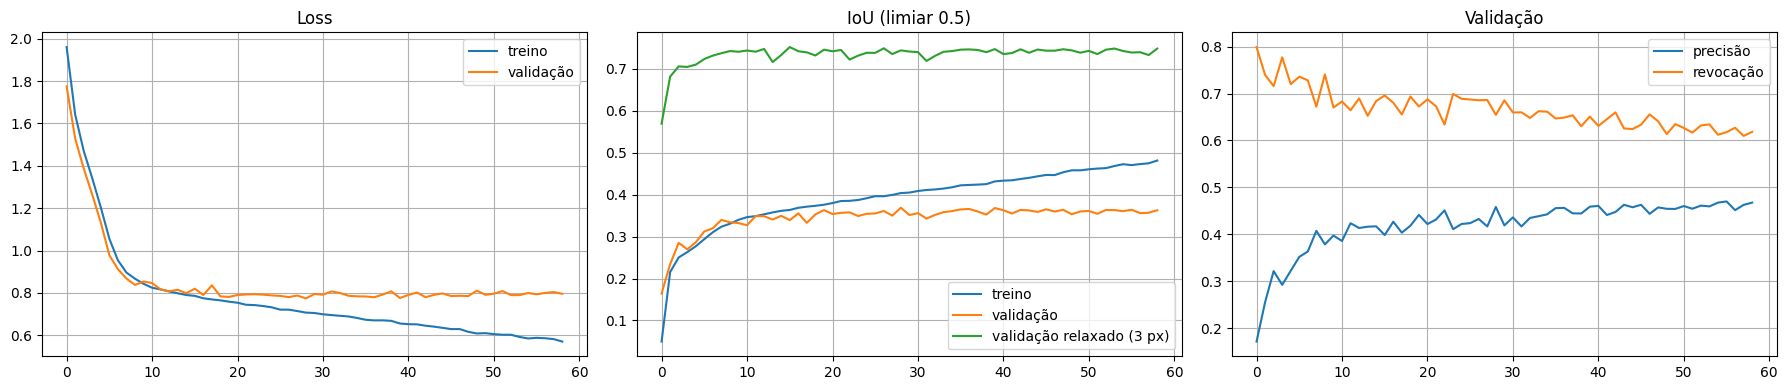

  limiar 0.10: IoU 0.3608
  limiar 0.15: IoU 0.3641
  limiar 0.20: IoU 0.3658
  limiar 0.25: IoU 0.3668
  limiar 0.30: IoU 0.3675
  limiar 0.35: IoU 0.3680
  limiar 0.40: IoU 0.3685
  limiar 0.45: IoU 0.3687
  limiar 0.50: IoU 0.3690
  limiar 0.55: IoU 0.3692
  limiar 0.60: IoU 0.3694
  limiar 0.65: IoU 0.3695
  limiar 0.70: IoU 0.3697
  limiar 0.75: IoU 0.3698
* limiar 0.80: IoU 0.3698
  limiar 0.85: IoU 0.3697
  limiar 0.90: IoU 0.3691
Melhor limiar: 0.80 (IoU 0.3698)
IoU sem pós-processamento: 0.3698
IoU com pós-processamento: 0.3696

Métricas no conjunto de TESTE (limiar 0.5):
   iou                0.3776
   precision          0.4690
   recall             0.6596
   f1                 0.5482
   relaxed_precision  0.9018
   relaxed_recall     0.8150
   relaxed_f1         0.8562
   relaxed_iou        0.7485

Métricas no conjunto de TESTE (limiar 0.80, escolhido na validação):
   iou                0.3789
   precision          0.4839
   recall             0.6360
   f1                 0

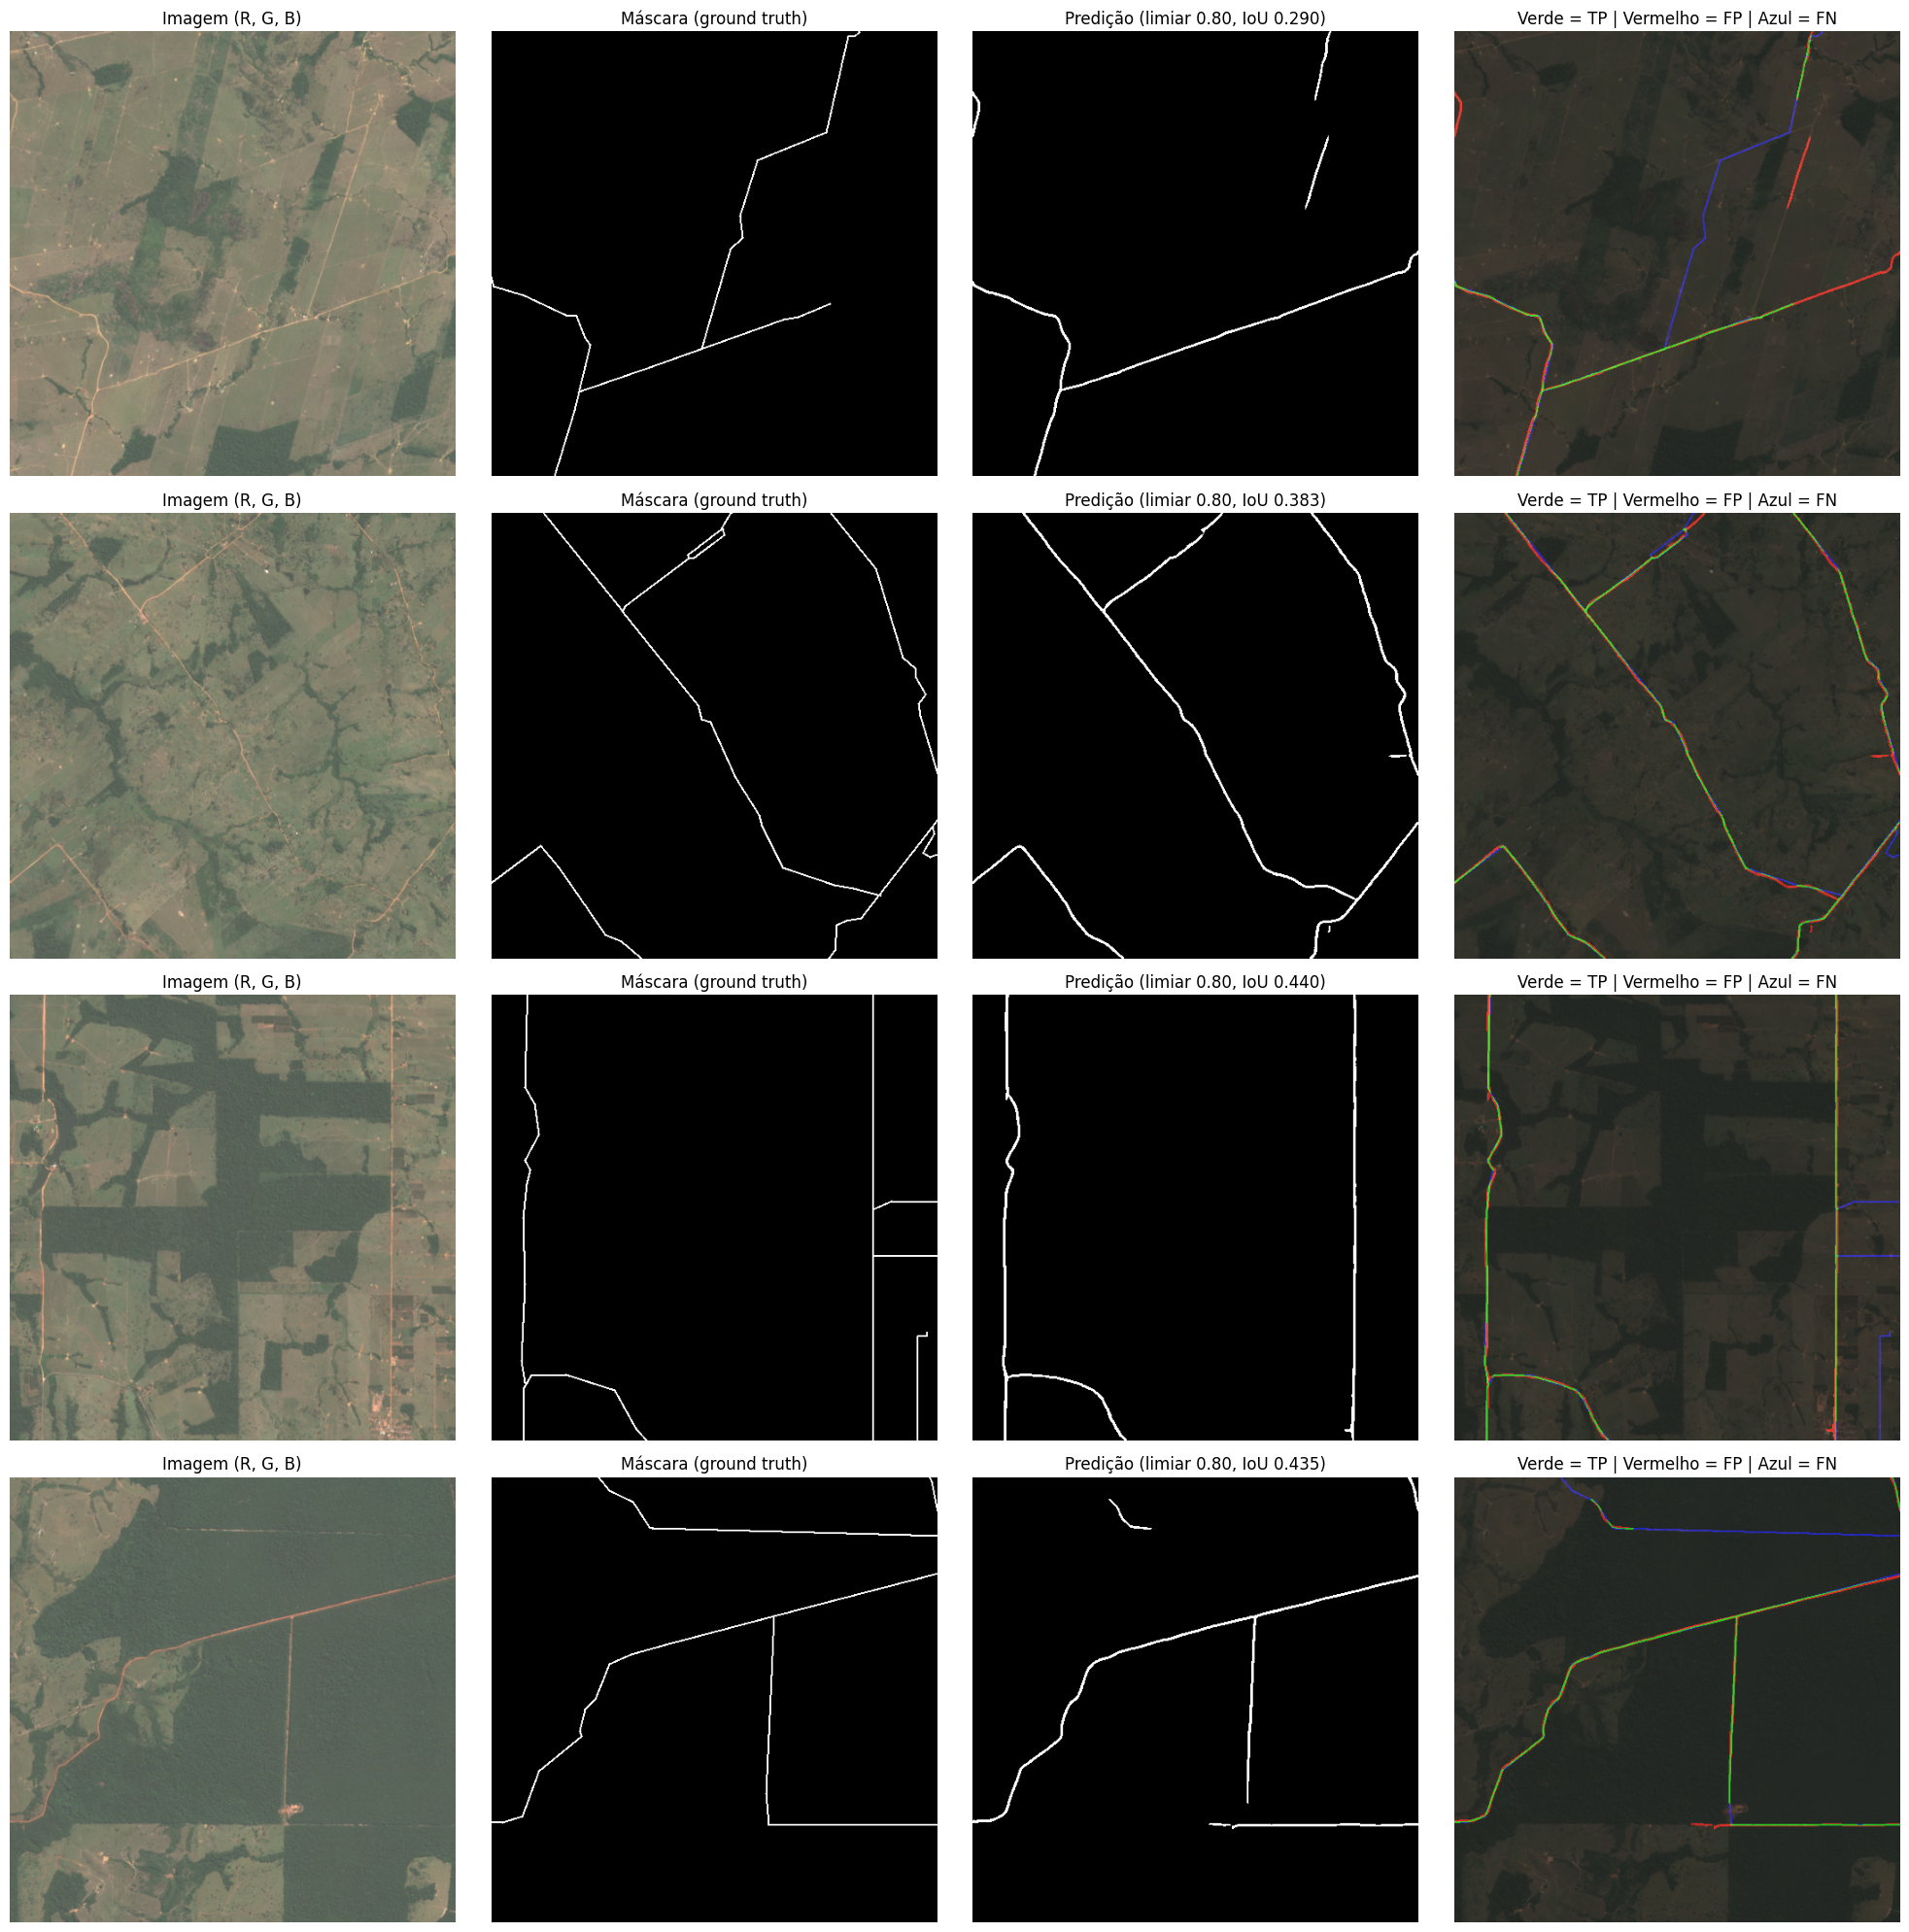

In [11]:
# ============================================================
# CÉLULA 9: TREINAR E AVALIAR
# ============================================================
set_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = criar_modelo()
history = train_model(model, train_loader, val_loader, device, NUM_EPOCHS)
plotar_historico(history)

# [CORREÇÃO 7] Avaliação com o MELHOR checkpoint (antes usava os pesos da última época)
model.load_state_dict(torch.load(CKPT_PATH, map_location=device))
model.to(device).eval()

# Escolhas feitas na VALIDAÇÃO: limiar e pós-processamento
melhor_t, _ = buscar_melhor_threshold(model, val_loader, device)
comparar_pos_processamento(model, val_loader, device, melhor_t)

# Números para reportar: TESTE, que não participou do treino, do checkpoint nem do limiar
if test_loader is not None:
    loader_final, nome_final = test_loader, "TESTE"
else:
    loader_final, nome_final = val_loader, "VALIDAÇÃO (sem teste separado, números otimistas)"
resultados = []
for t, rotulo in ((THRESHOLD, f"limiar {THRESHOLD}"), (melhor_t, f"limiar {melhor_t:.2f}, escolhido na validação")):
    res = avaliar(model, loader_final, device, threshold=t)
    resultados.append(res)
    print(f"\nMétricas no conjunto de {nome_final} ({rotulo}):")
    for k, v in res.items():
        print(f"   {k:18s} {v:.4f}")
registrar_experimento(model, history, resultados[0], resultados[1], melhor_t, nome_final)
visualize_predictions(model, loader_final, device, threshold=melhor_t)